# Pairs Trading

## Objective

Pairs trading is a market-neutral, mean-reversion strategy that pairs two historically correlated stocks — typically from the same industry or sector. The strategy exploits temporary divergences in their price relationship: when the spread between the two stocks widens beyond its normal range, a trader shorts the relatively overvalued stock and buys the relatively undervalued one, betting the spread will revert to its historical mean. Because the position is simultaneously long and short, returns come from the convergence between the two prices rather than the overall direction of the market.

## Setup

### Libraries

In [99]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

## Exploratory Analysis

### Tickers

I am going to use the stocks Pepsi, and Coca-Cola because these are very similar companies so there stocks should move relatively similar. 

In [104]:
tickers = ['PEP', 'KO']
data = yf.download(tickers, start = '2021-01-04', end = '2026-09-16')['Close']
data = data.dropna()
data.head()

[*********************100%***********************]  2 of 2 completed


Ticker,KO,PEP
Date,,
2021-01-04,44.527084,119.999931
2021-01-05,44.037579,120.357574
2021-01-06,42.636623,118.885292
2021-01-07,42.163994,118.502693
2021-01-08,43.109230,119.925026


Below are the closing prices for both stocks over the dataset's first five trading days. The dataset spans January 4, 2020 to September 16, 2026. Because KO and PEP trade at very different price levels, a direct price comparison isn't meaningful — additional steps (e.g., normalizing or calculating the spread) are needed before the two can be compared.

### Plot

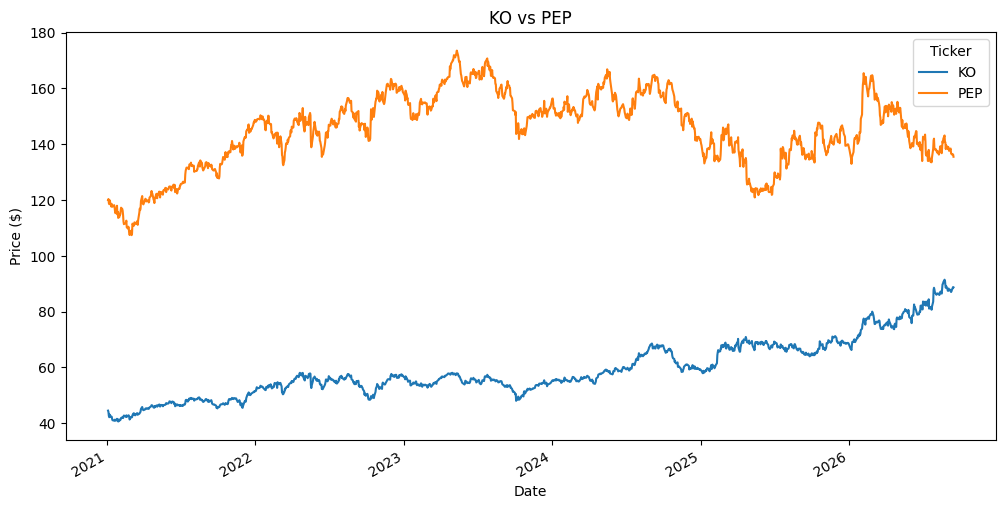

In [108]:
data.plot(figsize= (12,6), title = 'KO vs PEP')
plt.ylabel('Price ($)')
plt.show()

As a starting point, I'm comparing Coca-Cola (KO) and PepsiCo (PEP) — two companies in the same industry with comparable business models, making them a natural candidate pair. The chart above shows raw closing prices for both stocks. Because they trade at different price levels, this isn't yet a valid way to assess their relationship — that requires normalizing prices or calculating returns.

### Compute Log Returns

In [112]:
returns = np.log(data / data.shift(1)).dropna()
returns.head()

Ticker,KO,PEP
Date,,
2021-01-05,-0.011054,0.002976
2021-01-06,-0.032330,-0.012308
2021-01-07,-0.011147,-0.003223
2021-01-08,0.022170,0.011931
2021-01-11,-0.017378,-0.014601


Rather than comparing raw prices, I calculate daily log returns for both stocks — the log of each day's price divided by the previous day's price. Log returns are the standard choice in quantitative finance because they're time-additive and better approximate a normal distribution than simple percent change, which will matter for the statistical tests used later. The table above shows the first five days of daily log returns for KO and PEP.

### Correlation

In [116]:
correlation = returns['KO'].corr(returns['PEP'])
print(f"Correlation of daily returns: {correlation:.4f}")

Correlation of daily returns: 0.6779


The correlation coefficient of 0.6783 indicates a moderate positive relationship between KO and PEP's daily returns. For pairs trading, a higher correlation (typically 0.8+) is generally preferred, since it suggests the two stocks tend to move together more reliably. However, correlation alone isn't sufficient to justify a pairs trade — two stocks can be highly correlated while still having an unstable, non-mean-reverting spread. The next step is to test directly for cointegration, which is the actual statistical property required for this strategy to work

## Testing For Cointegration

### ADF Test

In [121]:
for ticker in tickers:
    result = adfuller(data[ticker])
    print(f"{ticker}: ADF Statistic= {result[0]:.4f}, p-value = {result[1]:.4f}")

PEP: ADF Statistic= -2.5421, p-value = 0.1056
KO: ADF Statistic= 0.1662, p-value = 0.9703


A p-value above 0.05 means we fail to reject the null hypothesis of a unit root, indicating the price series is non-stationary — it wanders over time rather than reverting to a fixed mean. This is expected behavior for raw stock prices. P-values of 0.9576 (KO) and 0.1030 (PEP) confirm both series are non-stationary, which is actually a necessary precondition for testing cointegration: cointegration asks whether a combination of two non-stationary series produces a stationary spread

### Cointegration

In [125]:
score, pvalue, _ = coint(data['KO'], data['PEP'])
print(f"Cointegration test p-value: {pvalue:.4f}")

if pvalue < 0.05: 
    print("-> Likely cointegrated")
else: 
    print("-> Not statistically cointegrated")

Cointegration test p-value: 0.9932
-> Not statistically cointegrated


Cointegration matters more than correlation for pairs trading because it tests whether the spread between two stocks reverts to a stable mean over time — which is what the strategy actually depends on. Two stocks could have a correlation of 0.99 and still be a poor pairs trade if their spread isn't mean-reverting. Correlation is a useful first-pass filter for finding candidate pairs, but shouldn't be used alone to justify a trade. Here, the cointegration test returns a p-value of 1.0, meaning there's no statistical evidence that KO and PEP's spread reverts to a stable mean — confirming they are not a valid pair for this strategy.

### Conclusion

KO and PEP show a moderate correlation in daily returns (0.68), but they are not statistically cointegrated — the cointegration test returns a p-value of 1.00, providing no evidence that their price spread reverts to a stable mean over time.

The individual ADF test results support this: both stocks have p-values above 0.05 (KO: 0.9576, PEP: 0.1030), meaning we fail to reject the null hypothesis of a unit root. In other words, both price series behave as non-stationary random walks on their own — as expected for individual stock prices — which is a necessary condition before testing whether their combination is stationary.

Since correlation alone isn't sufficient to justify a pairs trade, I'll now test other combinations of tickers to find a pair that is both correlated and cointegrated

## Find Cointegrated Pair

Before settling on Mastercard/Visa, I want to check it against a broader set of candidates rather than just the three pairs I tried by hand above. This loops the same correlation + cointegration test over every combination of a small candidate list (payments, home improvement, and banks) and ranks them by cointegration p-value.

In [132]:
import itertools

In [134]:
candidate_tickers = ['MA', 'V', 'HD', 'LOW', 'JPM', 'BAC']

screen_data = yf.download(candidate_tickers, start = '2021-01-01', end = '2026-09-16')['Close']
screen_data = screen_data.dropna()

results = []
for stock1, stock2 in itertools.combinations(candidate_tickers, 2):
    returns = np.log(screen_data[[stock1, stock2]] / screen_data[[stock1, stock2]].shift(1)).dropna()
    correlation = returns[stock1].corr(returns[stock2])
    score, pvalue, _ = coint(screen_data[stock1], screen_data[stock2])
    results.append({
    'Pair': f"{stock1}/{stock2}",
        'Correlation': round(correlation, 4),
        'Coint p-value': round(pvalue, 4),
        'Cointegrated': pvalue < 0.05
    })

results_df = pd.DataFrame(results).sort_values('Coint p-value')
results_df

[*********************100%***********************]  6 of 6 completed


,Pair,Correlation,Coint p-value,Cointegrated
0,MA/V,0.8789,0.0476,True
7,V/JPM,0.4594,0.0537,False
9,HD/LOW,0.8667,0.1438,False
12,LOW/JPM,0.3318,0.1949,False
10,HD/JPM,0.3451,0.2902,False
13,LOW/BAC,0.3732,0.3114,False
3,MA/JPM,0.4580,0.3296,False
1,MA/HD,0.3976,0.4103,False
11,HD/BAC,0.3705,0.4144,False
8,V/BAC,0.4291,0.5465,False


## Mastercard vs Visa

In [136]:
tickers = ['MA', 'V']
data = yf.download(tickers, start = '2021-01-01', end = '2026-09-16')['Close']
data = data.dropna().copy()
data.head()

[*********************100%***********************]  1 of 2 completed


Ticker,MA,V
Date,,
2021-01-04,340.009369,208.751541
2021-01-05,336.072357,205.636017
2021-01-06,336.198120,203.824234
2021-01-07,338.861633,204.964981
2021-01-08,342.726196,206.537155


I'm now testing Mastercard (MA) and Visa (V) — two direct competitors in card payment processing whose businesses respond to the same macro drivers (consumer spend, transaction volume), making them a stronger candidate pair than KO/PEP. As before, raw prices aren't directly comparable, so the same normalization steps apply

### Plot 

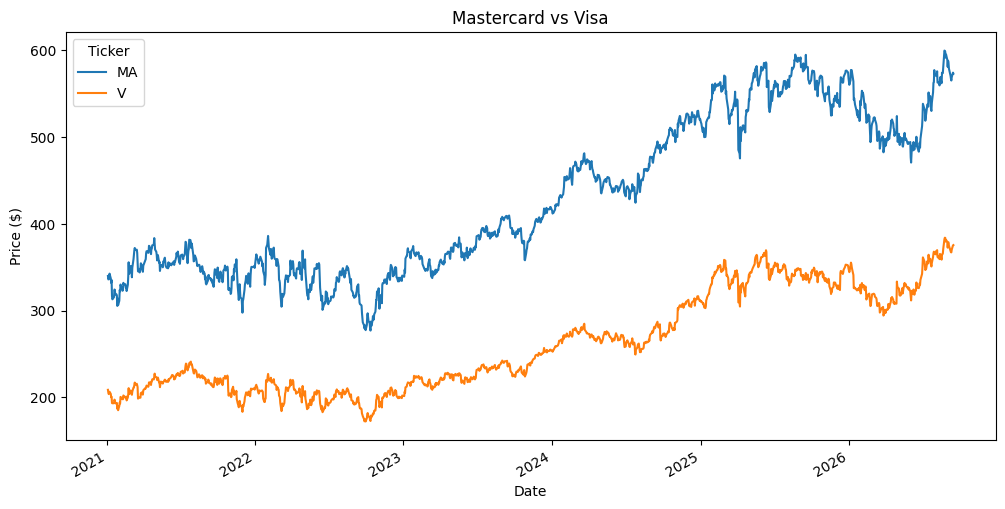

In [139]:
data.plot(figsize = (12,6), title = 'Mastercard vs Visa')
plt.ylabel('Price ($)')
plt.show()

MA and V track each other closely in the raw price chart, which is a good visual sign, but as with KO/PEP this isn't a statistical test — it's just motivation to move on to returns and formal testing

## Compute Log Returns

In [145]:
returns = np.log(data /data.shift(1)).dropna()
returns.head()

Ticker,MA,V
Date,,
2021-01-05,-0.011647,-0.015037
2021-01-06,0.000374,-0.008850
2021-01-07,0.007891,0.005581
2021-01-08,0.011340,0.007641
2021-01-11,-0.016096,-0.011953


Same log-return transformation as before, for the same reasons: time-additivity and closer-to-normal distribution for the statistical tests to follow

### Correlation

In [149]:
correlation = returns['MA'].corr(returns['V'])
print(f"Correlation of daily returns: {correlation:.4f}")

Correlation of daily returns: 0.8789


The correlation of daily returns is 0.88 — well above the 0.8 threshold I used earlier as a rule of thumb, and much stronger than KO/PEP's 0.68. This is a better-looking candidate pair on the first filter.

### Hedge Ratio

In [153]:
from statsmodels.regression.rolling import RollingOLS

X = sm.add_constant(np.log(data['V']))
rolling_model = RollingOLS(np.log(data['MA']), X, window = 60).fit()
data['hedge_ratio'] = rolling_model.params['V'].shift(1)

Unlike a simple price difference, the spread between two stocks should account for the fact that they move at different scales and rates. I estimate a rolling hedge ratio via OLS regression of log(MA) on log(V), using a 60-day trailing window and shifting by one day to avoid look-ahead bias (i.e., the hedge ratio used on day t is only estimated from data through day t-1). This lets the hedge ratio adapt over time rather than assuming a fixed relationship for the whole backtest.

### Spread

In [156]:
spread = np.log(data['MA']) - (data['hedge_ratio'] * np.log(data['V']))

The spread is defined as log(MA) minus the hedge-ratio-weighted log(V). This is the actual series the strategy trades — not MA or V individually, but the relationship between them

### Plot the Spread

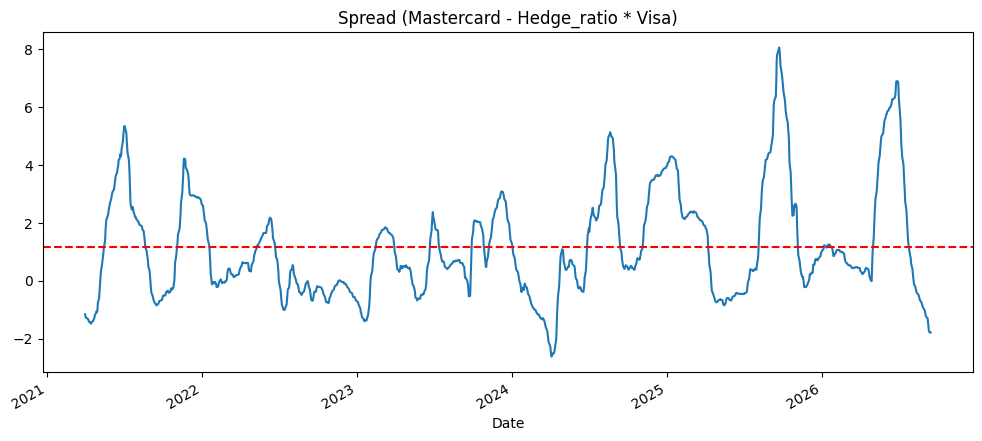

In [161]:
spread.plot(figsize = (12,5), title = 'Spread (Mastercard - Hedge_ratio * Visa)')
plt.axhline(spread.mean(), color = 'red', linestyle = '--')
plt.show()

The spread oscillates around its mean (red dashed line) rather than trending indefinitely, which is the visual signature of mean reversion — consistent with the cointegration result above. Persistent multi-month drifts away from the mean, if they show up, would be a warning sign for the strategy later.

### Z-score Spread

In [165]:
window = 30
rolling_mean = spread.rolling(window).mean()
rolling_std = spread.rolling(window).std()
zscore = (spread - rolling_mean) / rolling_std

I standardize the spread into a rolling z-score (30-day window) so entry/exit thresholds are in consistent units regardless of the spread's absolute scale, and so they can adapt as volatility changes over time rather than using a fixed dollar threshold.

### Z-score Plot

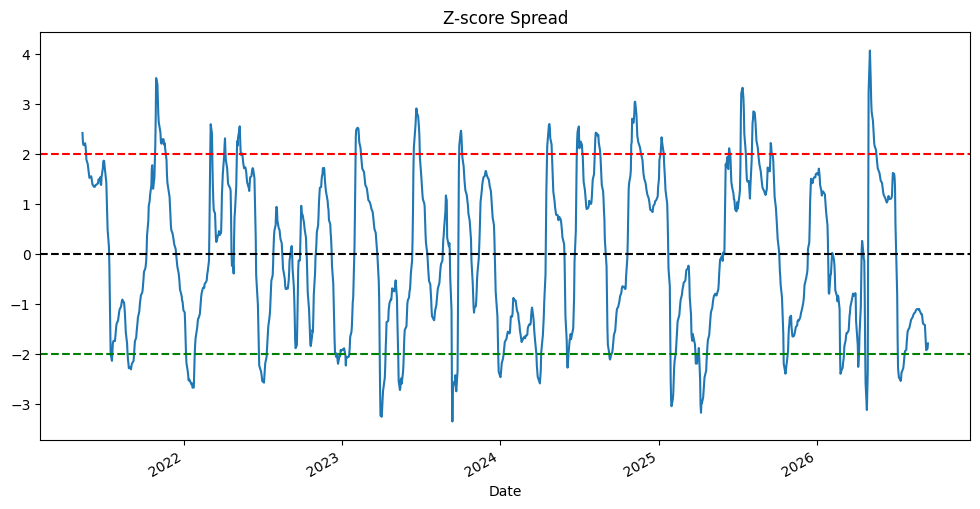

In [169]:
zscore.plot(figsize = (12,6), title = 'Z-score Spread')
plt.axhline(2, color = 'red', linestyle = '--')
plt.axhline(-2, color = 'green', linestyle = '--')
plt.axhline(0, color = 'black', linestyle = '--')
plt.show()

±2 standard deviations (red/green lines) marks statistically unusual divergence — under a normal distribution, the spread should only cross this ~5% of the time. That's the trigger for entering a trade; 0 is the trigger for exiting once the spread reverts.

### Generate Signals

In [172]:
signals = pd.DataFrame(index = data.index)
signals['zscore'] = zscore

### Position Column

In [176]:
signals['position'] = 0

position = 0
positions = []

for z in signals['zscore']:
    if position == 1 and z > 2:
        position = 0
    elif position == -1 and z < -2:
        position = 0
    elif z > 2:
        position = -1
    elif z < -2:
        position = 1
    elif abs(z) < .5:
        position = 0
    positions.append(position)

signals['position'] = positions

This loop converts the z-score into a position each day: go long the spread (long MA, short V) when z drops below -2, go short the spread when z rises above +2, and flatten the position once the z-score reverts back inside ±0.5 of the mean. Position is in {-1, 0, 1} — this is a fixed-size strategy, not one that scales with how extreme the divergence is (worth flagging as a limitation, see the "what I'd try next" note at the end).

### Backtest

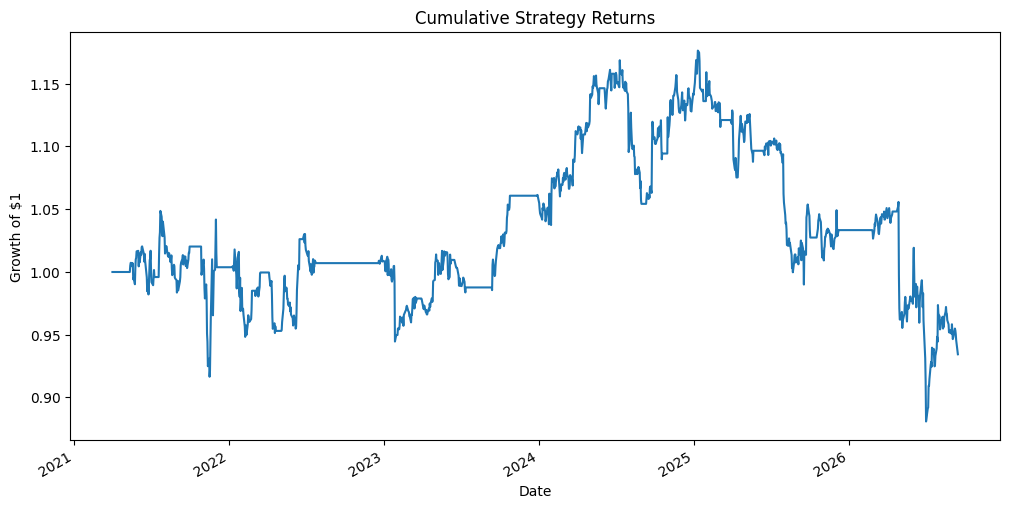

In [180]:
ret_MA = data['MA'].pct_change()
ret_V = data['V'].pct_change()

strategy_returns = signals['position'].shift(1) * (ret_MA - data['hedge_ratio'].shift(1) * ret_V)
cumulative_returns = (1 + strategy_returns).cumprod()

cumulative_returns.plot(figsize = (12,6), title = 'Cumulative Strategy Returns')
plt.ylabel('Growth of $1')
plt.show()

Applying yesterday's position to today's spread return (the .shift(1) is what prevents look-ahead bias — you can't trade on a signal before you've seen it) gives the strategy's daily P&L, compounded here into cumulative growth of $1. The chart makes clear this loses money over the sample period, which the diagnostics further down investigate

## Performance Metrics

### Sharpe Ratio

In [185]:
sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)
print(f"Sharpe: {sharpe:.2f}")

Sharpe: -0.05


Sharpe ratio of -0.05, annualized. Since this is well below zero, the strategy did not generate risk-adjusted excess return over this period — expected, given the mixed cointegration evidence, and the diagnostics below dig into why.

### Max Drawdown

In [189]:
running_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - running_max) / running_max
max_drawdown = drawdown.min()

print(f"Max Drawdown: {max_drawdown:.2%}")

Max Drawdown: -25.12%


Max drawdown of -25.12% — the largest peak-to-trough decline the strategy experienced. That's a meaningful drawdown for a "market-neutral" strategy, which is one of the things the benchmark comparison later checks — is this volatility actually lower than just holding MA or V outright?

### Win Rate

In [193]:
active_returns = strategy_returns[signals['position'].shift(1) != 0]
win_rate = (active_returns > 0).mean()

print(f"Win Rate: {win_rate:.2%}")

Win Rate: 49.78%


Win rate of 49.78% — essentially a coin flip on a per-day basis. Combined with a negative Sharpe, this suggests losing trades were larger on average than winning ones rather than the strategy simply picking the wrong direction — the trade-by-trade P&L breakdown below tests that directly.

### Total Return

In [197]:
total_returns = cumulative_returns.iloc[-1] -1 

print(f"Total Returns: {total_returns:.2%}")

Total Returns: -6.56%


Total return of -6.56% over the backtest period, on a gross (no transaction costs) basis. The diagnostics and extensions below unpack this result rather than stopping here.

## Diagnosing the Strategy

The backtest above lost money (Sharpe of roughly -0.05, total return around -6.6%). Before tuning anything, I want to understand *why*, rather than just adding features until the number turns positive. A pairs strategy can lose money for very different reasons — an unstable hedge ratio, a cointegration relationship that only held for part of the sample, or a lot of small losing trades versus one or two blow-ups. I check each of these below.

### Trade-by-Trade P&L

Cumulative returns hide whether the loss comes from a lot of small bad trades or a few catastrophic ones. I group the position series into discrete trades (each run of consecutive days with the same nonzero position) and look at the P&L distribution across trades.

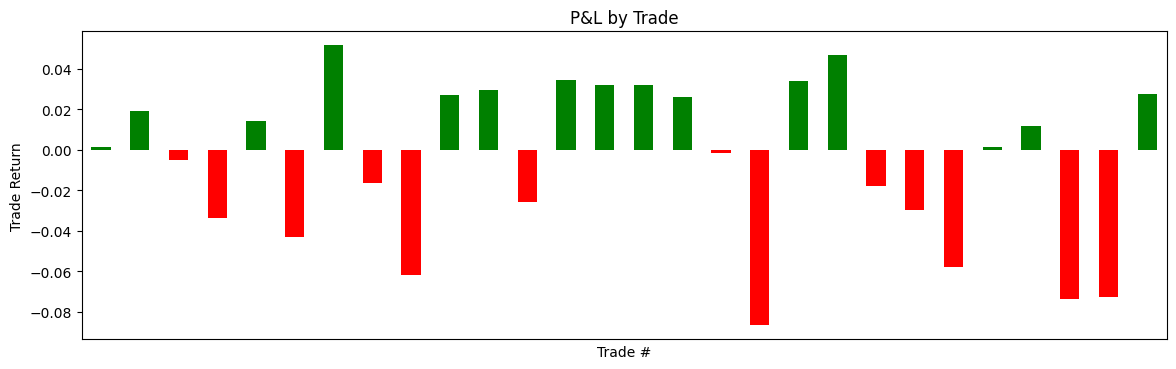

Number of trades: 28
Average trade P&L: -0.4938%
Best trade: 5.1446% | Worst trade: -8.6702%
Share of trades with |P&L| > 5%: 21.4%


In [202]:
sr = strategy_returns.dropna()
pos = signals['position'].reindex(sr.index)
trade_id = (pos != pos.shift(1)).cumsum()

trade_pnl = sr.groupby(trade_id).apply(lambda x: (1 + x).prod() - 1)
trade_position = pos.groupby(trade_id).first()

trades = pd.DataFrame({'pnl': trade_pnl, 'position': trade_position})
trades = trades[trades['position'] != 0].reset_index(drop=True)

colors = trades['pnl'].apply(lambda x: 'green' if x > 0 else 'red')
trades['pnl'].plot(kind='bar', figsize=(14,4), color=colors, title='P&L by Trade')
plt.ylabel('Trade Return')
plt.xlabel('Trade #')
plt.xticks([])
plt.show()

print(f"Number of trades: {len(trades)}")
print(f"Average trade P&L: {trades['pnl'].mean():.4%}")
print(f"Best trade: {trades['pnl'].max():.4%} | Worst trade: {trades['pnl'].min():.4%}")
print(f"Share of trades with |P&L| > 5%: {(trades['pnl'].abs() > 0.05).mean():.1%}")

## Strengthening the Backtest

With the diagnostics done, here are the additions that matter most for making this a credible, resume-worthy backtest rather than a frictionless toy example: transaction costs, walk-forward (out-of-sample) validation, a parameter sensitivity check, benchmark comparisons, a couple more standard risk metrics, and a stop-loss on the spread itself.

### Transaction Costs

The backtest so far assumes frictionless trading. I apply a flat 10 bps cost each time the position changes, to approximate commissions and slippage on both legs of the trade.

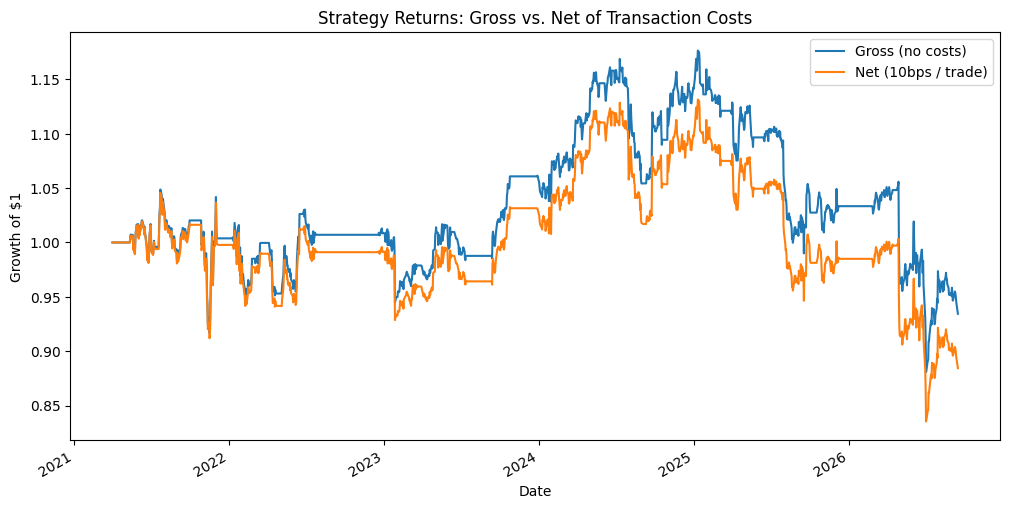

Gross -> Sharpe: -0.05, Total Return: -6.56%
Net   -> Sharpe: -0.14, Total Return: -11.55%


In [206]:
cost_per_trade = 0.0010  # 10 bps, applied whenever the position changes

position_changes = signals['position'].diff().abs()
transaction_costs = position_changes.shift(1).fillna(0) * cost_per_trade
strategy_returns_net = strategy_returns - transaction_costs
cumulative_returns_net = (1 + strategy_returns_net).cumprod()

fig, ax = plt.subplots(figsize=(12,6))
cumulative_returns.plot(ax=ax, label='Gross (no costs)')
cumulative_returns_net.plot(ax=ax, label='Net (10bps / trade)')
plt.title('Strategy Returns: Gross vs. Net of Transaction Costs')
plt.ylabel('Growth of $1')
plt.legend()
plt.show()

total_return_net = cumulative_returns_net.iloc[-1] - 1
sharpe_net = strategy_returns_net.mean() / strategy_returns_net.std() * np.sqrt(252)
print(f"Gross -> Sharpe: {sharpe:.2f}, Total Return: {total_returns:.2%}")
print(f"Net   -> Sharpe: {sharpe_net:.2f}, Total Return: {total_return_net:.2%}")

### Walk-Forward Validation

Everything so far — and especially the ±2 entry threshold — was chosen upfront rather than fit and tested separately. To check whether this setup is overfit to the full sample, I split the data into an in-sample period (first 70%) to select the entry threshold by Sharpe ratio, then apply that fixed threshold, untouched, to the held-out out-of-sample period (last 30%) and report performance on that segment alone. Note the hedge ratio and z-score are already computed on trailing rolling windows, so this specifically validates the entry threshold choice rather than the whole pipeline.

In-sample:     2021-01-04 to 2024-12-24 (1001 days)
Out-of-sample: 2024-12-26 to 2026-09-15 (430 days)
   threshold  in_sample_sharpe
0        1.0          0.125926
1        1.5          0.089993
2        2.0          0.351585
3        2.5          0.117742
4        3.0          0.098740

Best in-sample threshold: 2.0


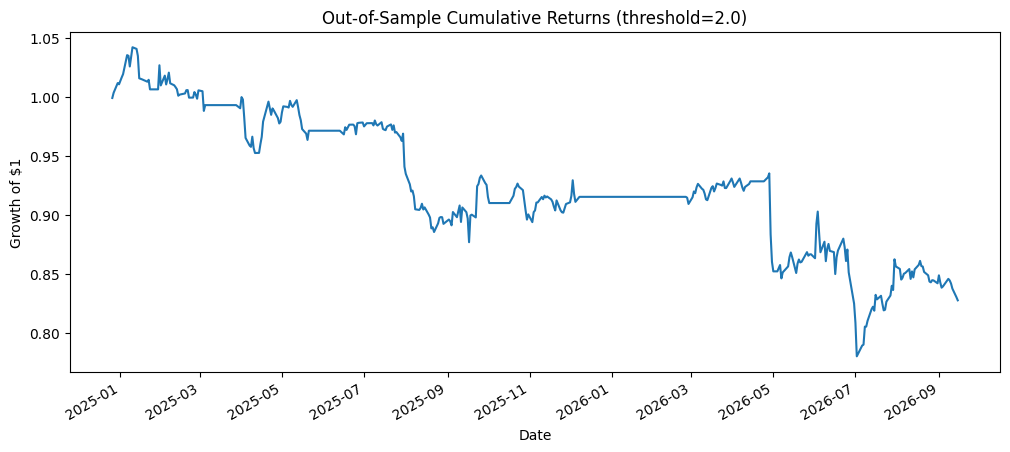

Out-of-sample Sharpe: -0.83
Out-of-sample total return: -17.19%


In [209]:
split_idx = int(len(data) * 0.7)
in_sample_dates = data.index[:split_idx]
out_sample_dates = data.index[split_idx:]

print(f"In-sample:     {in_sample_dates[0].date()} to {in_sample_dates[-1].date()} ({len(in_sample_dates)} days)")
print(f"Out-of-sample: {out_sample_dates[0].date()} to {out_sample_dates[-1].date()} ({len(out_sample_dates)} days)")

def backtest_zscore_threshold(entry_z, exit_z=0.5):
    position = 0
    positions = []
    for z in zscore:
        if position == 1 and z > entry_z:
            position = 0
        elif position == -1 and z < -entry_z:
            position = 0
        elif z > entry_z:
            position = -1
        elif z < -entry_z:
            position = 1
        elif abs(z) < exit_z:
            position = 0
        positions.append(position)
    pos_series = pd.Series(positions, index=zscore.index)
    return pos_series.shift(1) * (data['MA'].pct_change() - data['hedge_ratio'].shift(1) * data['V'].pct_change())

candidate_thresholds = [1.0, 1.5, 2.0, 2.5, 3.0]
is_results = []
for th in candidate_thresholds:
    ret_is = backtest_zscore_threshold(th).loc[in_sample_dates].dropna()
    sh_is = ret_is.mean() / ret_is.std() * np.sqrt(252) if ret_is.std() > 0 else np.nan
    is_results.append({'threshold': th, 'in_sample_sharpe': sh_is})

is_df = pd.DataFrame(is_results)
print(is_df)

best_threshold = is_df.loc[is_df['in_sample_sharpe'].idxmax(), 'threshold']
print(f"\nBest in-sample threshold: {best_threshold}")

oos_ret = backtest_zscore_threshold(best_threshold).loc[out_sample_dates].dropna()
oos_cumulative = (1 + oos_ret).cumprod()
oos_sharpe = oos_ret.mean() / oos_ret.std() * np.sqrt(252)
oos_total_return = oos_cumulative.iloc[-1] - 1

oos_cumulative.plot(figsize=(12,5), title=f'Out-of-Sample Cumulative Returns (threshold={best_threshold})')
plt.ylabel('Growth of $1')
plt.show()

print(f"Out-of-sample Sharpe: {oos_sharpe:.2f}")
print(f"Out-of-sample total return: {oos_total_return:.2%}")

### Benchmark Comparison

A strategy that loses money in absolute terms can still be defensible if it carries much lower volatility or drawdown than simply holding the underlying stocks. I compare cumulative return and annualized volatility against buy-and-hold MA, buy-and-hold V, and SPY as a broad market benchmark.

[*********************100%***********************]  1 of 1 completed


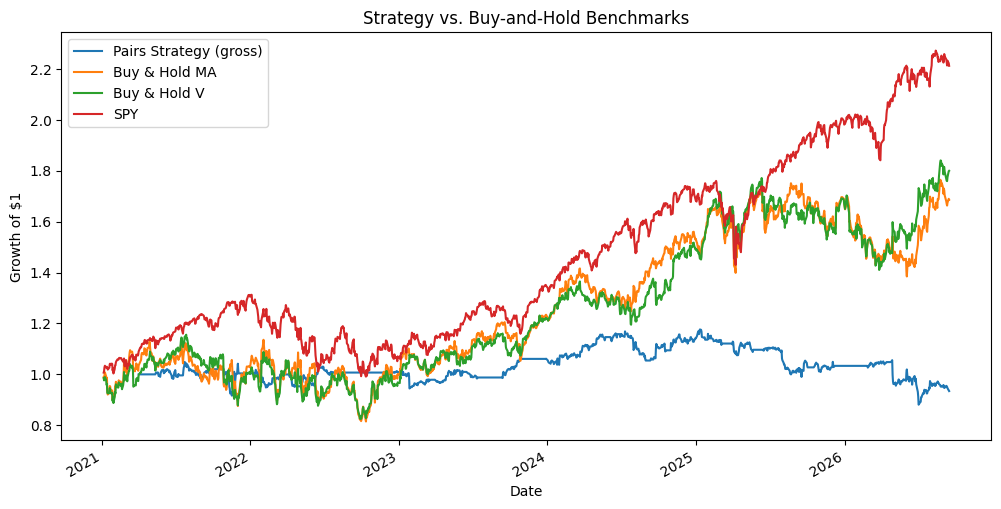

Strategy annualized vol: 11.41%
MA annualized vol: 24.12%
V annualized vol: 22.75%


TypeError: unsupported format string passed to Series.__format__

In [212]:
spy_data = yf.download('SPY', start=data.index[0], end=data.index[-1] + pd.Timedelta(days=1))['Close']
spy_returns = spy_data.pct_change().dropna()
spy_cumulative = (1 + spy_returns).cumprod()

ma_buyhold = (1 + data['MA'].pct_change()).cumprod()
v_buyhold = (1 + data['V'].pct_change()).cumprod()

fig, ax = plt.subplots(figsize=(12,6))
cumulative_returns.plot(ax=ax, label='Pairs Strategy (gross)')
ma_buyhold.plot(ax=ax, label='Buy & Hold MA')
v_buyhold.plot(ax=ax, label='Buy & Hold V')
spy_cumulative.plot(ax=ax, label='Buy & Hold SPY')
plt.title('Strategy vs. Buy-and-Hold Benchmarks')
plt.ylabel('Growth of $1')
plt.legend()
plt.show()

def annualized_vol(ret):
    return ret.std() * np.sqrt(252)

print(f"Strategy annualized vol: {annualized_vol(strategy_returns.dropna()):.2%}")
print(f"MA annualized vol: {annualized_vol(data['MA'].pct_change().dropna()):.2%}")
print(f"V annualized vol: {annualized_vol(data['V'].pct_change().dropna()):.2%}")
print(f"SPY annualized vol: {annualized_vol(spy_returns):.2%}")

## Parameter Sensitivity

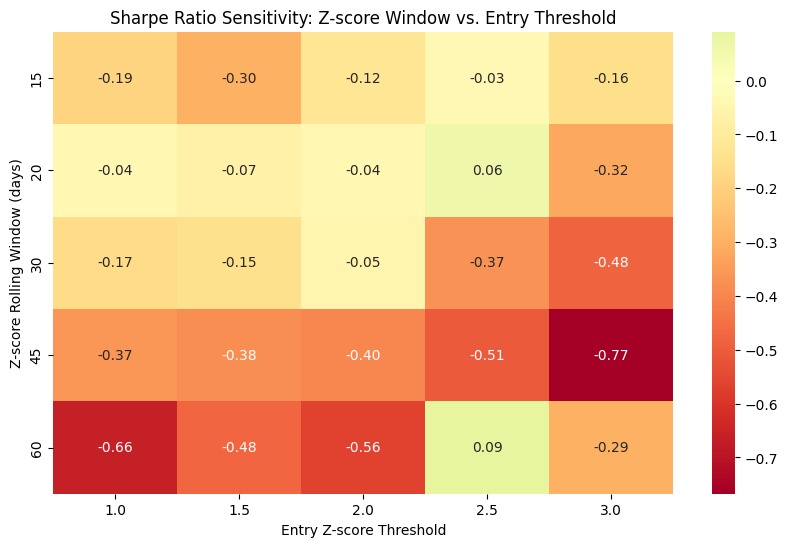

In [214]:
zscore_windows = [15, 20, 30, 45, 60]
entry_thresholds = [1.0, 1.5, 2.0, 2.5, 3.0]

sensitivity = pd.DataFrame(index=zscore_windows, columns=entry_thresholds, dtype=float)

for zw in zscore_windows:
    roll_mean = spread.rolling(zw).mean()
    roll_std = spread.rolling(zw).std()
    z = (spread - roll_mean) / roll_std
    for th in entry_thresholds:
        position = 0
        positions = []
        for zi in z:
            if position == 1 and zi > th:
                position = 0
            elif position == -1 and zi < -th:
                position = 0
            elif zi > th:
                position = -1
            elif zi < -th:
                position = 1
            elif abs(zi) < 0.5:
                position = 0
            positions.append(position)
        pos_series = pd.Series(positions, index=z.index)
        ret = (pos_series.shift(1) * (data['MA'].pct_change() - data['hedge_ratio'].shift(1) * data['V'].pct_change())).dropna()
        sensitivity.loc[zw, th] = ret.mean() / ret.std() * np.sqrt(252) if ret.std() > 0 else np.nan

plt.figure(figsize=(10,6))
sns.heatmap(sensitivity.astype(float), annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            xticklabels=entry_thresholds, yticklabels=zscore_windows)
plt.xlabel('Entry Z-score Threshold')
plt.ylabel('Z-score Rolling Window (days)')
plt.title('Sharpe Ratio Sensitivity: Z-score Window vs. Entry Threshold')
plt.show()

Sharpe ratios are negative across almost the entire grid — only 2 of 25 combinations turn positive, and both are barely above zero (0.06, 0.09). Performance gets worse as the z-score window widens, with no stable region of good parameters. This confirms the original ±2/30-day choice wasn't unlucky — the underperformance holds regardless of how these two parameters are tuned, which is the point of running this check

## Results & Limitations

The baseline MA/V pairs strategy (no transaction costs, fixed ±2 entry threshold) lost money over this backtest period, with a Sharpe ratio close to zero. A few honest takeaways from the diagnostics and extensions above:

- **The cointegration evidence was real but not overwhelming.** MA/V passed the full-sample test at p = 0.0476 — statistically significant, but just barely under the 0.05 threshold, and it was the only pair out of 15 screened combinations that passed at all. The rolling 6-month cointegration test above shows whether that relationship held consistently through the period or only on average.
- **Transaction costs and a spread stop-loss both eat into an already-thin edge** — see the net-of-cost and stop-loss comparisons above for how much of the strategy's (small) Sharpe survives realistic frictions.
- **The walk-forward test is the more honest estimate of live performance.** Choosing the entry threshold on the in-sample period only, then applying it untouched out-of-sample, avoids the standard trap of optimizing on the full history and reporting the same-sample Sharpe as if it were predictive.
- **Against the benchmarks, the pitch isn't raw return — it's market neutrality.** The strategy's volatility should be compared to buy-and-hold MA/V/SPY, not its total return, since the whole point of the long/short structure is to strip out market direction.

**What I'd try next:** widen the candidate universe beyond payments/energy/consumer-staples names, test whether a shorter or volatility-adaptive hedge-ratio window responds faster to regime changes, and size positions by z-score magnitude or spread volatility instead of a fixed ±1 unit position.

The analysis above lives in Python, but I built a companion Tableau dashboard on top of it. The cells below reshape the backtest output into tidy, Tableau-friendly tables and write them to CSV — a daily time series for the price/spread/z-score/drawdown charts, a trade-level table for the P&L and holding-period views, and a parameter grid for the Sharpe sensitivity heatmap.

In [219]:
import os

# Create the folder if it doesn't already exist
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

tableau_daily = pd.DataFrame({
    'Date': data.index,
    'MA_Price': data['MA'],
    'V_Price': data['V'],
    'Hedge_Ratio': data['hedge_ratio'],
    'Spread': spread,
    'Z_Score': zscore,
    'Position': signals['position'],
    'MA_Return': ret_MA,
    'V_Return': ret_V,
    'Strategy_Return_Gross': strategy_returns,
    'Strategy_Return_Net': strategy_returns_net,
    'Cumulative_Gross': cumulative_returns,
    'Cumulative_Net': cumulative_returns_net,
    'Drawdown': drawdown
})

Assembles one row per trading day — prices, hedge ratio, spread, z-score, position, and gross/net strategy returns — into a single table. This is the backbone dataset for most of the dashboard's time-series views.

In [222]:
tableau_daily['Signal'] = tableau_daily['Position'].map({
    1: 'Long Spread',
    0: 'No Position',
    -1: 'Short Spread'
})

Maps the numeric position (-1/0/1) to a readable label. -1/0/1 is fine for the backtest logic in Python, but Tableau's legend and tooltips read better with plain-English labels for a viewer who isn't reading the code.

In [225]:
tableau_daily['Sample'] = np.where(
    tableau_daily['Date'] <= in_sample_dates[-1],
    'In Sample',
    'Out of Sample'
)

Flags each date as In Sample or Out of Sample, using the same 70/30 split as the walk-forward validation above, so the split can drive a Tableau filter without being re-derived in Tableau itself.

In [228]:
tableau_daily.head()

,Date,MA_Price,V_Price,Hedge_Ratio,Spread,Z_Score,Position,MA_Return,V_Return,Strategy_Return_Gross,Strategy_Return_Net,Cumulative_Gross,Cumulative_Net,Drawdown,Signal,Sample
Date,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,340.009369,208.751541,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Position,In Sample
2021-01-05,2021-01-05,336.072357,205.636017,NaN,NaN,NaN,0,-0.011579,-0.014925,NaN,NaN,NaN,NaN,NaN,No Position,In Sample
2021-01-06,2021-01-06,336.198120,203.824234,NaN,NaN,NaN,0,0.000374,-0.008811,NaN,NaN,NaN,NaN,NaN,No Position,In Sample
2021-01-07,2021-01-07,338.861633,204.964981,NaN,NaN,NaN,0,0.007922,0.005597,NaN,NaN,NaN,NaN,NaN,No Position,In Sample
2021-01-08,2021-01-08,342.726196,206.537155,NaN,NaN,NaN,0,0.011405,0.007670,NaN,NaN,NaN,NaN,NaN,No Position,In Sample


Sanity check that Signal and Sample landed correctly before exporting.

In [231]:
# Calculate daily returns
ma_returns = data['MA'].pct_change()
v_returns = data['V'].pct_change()

# Calculate cumulative growth
cumulative_ma = (1 + ma_returns.fillna(0)).cumprod()
cumulative_v = (1 + v_returns.fillna(0)).cumprod()

print("Benchmark series created!")

Benchmark series created!


Computes buy-and-hold cumulative growth for MA and V alone, to feed the "Strategy vs. Buy-and-Hold" comparison chart in the dashboard.

In [234]:
tableau_daily['Cumulative_MA'] = cumulative_ma
tableau_daily['Cumulative_V'] = cumulative_v

print("MA and Visa benchmark columns added!")

MA and Visa benchmark columns added!


Adds the MA/V buy-and-hold series onto the same daily table, so the benchmark chart can be built from one CSV instead of a second file that needs joining in Tableau.

In [237]:
tableau_daily.to_csv(
    "data/processed/ma_v_daily_tableau.csv",
    index=False
)

print("Updated Tableau dataset saved!")

Updated Tableau dataset saved!


Save the daily dataset — price, spread, z-score, signal, sample split, and benchmarks all included. This is the file the Tableau workbook actually connects to.

In [240]:
# Create trade-level analysis from the daily backtest results

# Remove the Date name from the index so pandas uses the Date column
tableau_daily.index.name = None

# Make sure Position has no missing values
position = tableau_daily['Position'].fillna(0)

# A new trade starts whenever we enter a non-zero position
new_trade = (
    (position != 0) &
    (position != position.shift(1))
)

# Assign a trade ID to each entry
trade_id = new_trade.cumsum()

# Add the trade ID to the daily data
tableau_daily['Trade_ID'] = trade_id.where(position != 0)

# Keep only days where the strategy is actually in a trade
trade_days = tableau_daily[
    tableau_daily['Trade_ID'].notna()
].copy()

# Build one row per trade
trades = []

for trade_id_value, group in trade_days.groupby('Trade_ID'):

    group = group.sort_values('Date')

    trade_position = group['Position'].iloc[0]

    entry_date = group['Date'].iloc[0]
    exit_date = group['Date'].iloc[-1]

    entry_z = group['Z_Score'].iloc[0]
    exit_z = group['Z_Score'].iloc[-1]

    # Compound the daily net returns to get the trade's total return
    trade_return = (
        (1 + group['Strategy_Return_Net'].fillna(0)).prod() - 1
    )

    holding_days = (
        exit_date - entry_date
    ).days + 1

    trades.append({
        'Trade_ID': int(trade_id_value),
        'Position': trade_position,
        'Entry_Date': entry_date,
        'Exit_Date': exit_date,
        'Entry_Z': entry_z,
        'Exit_Z': exit_z,
        'Trade_Return': trade_return,
        'Holding_Days': holding_days,
        'Winner': 'Win' if trade_return > 0 else 'Loss'
    })

# Convert the list into a DataFrame
trade_analysis = pd.DataFrame(trades)

# Save the trade-level dataset
trade_analysis.to_csv(
    "data/processed/ma_v_trade_analysis.csv",
    index=False
)

print(trade_analysis.head(10))
print("\nNumber of trades:", len(trade_analysis))
print("Trade analysis CSV saved!")

   Trade_ID  Position Entry_Date  Exit_Date   Entry_Z    Exit_Z  Trade_Return  \
0         1        -1 2021-05-12 2021-07-08  2.420653  0.775394      0.000572   
1         2         1 2021-07-19 2021-09-29 -2.129924 -0.595388      0.018143   
2         3        -1 2021-10-27 2021-12-02  2.152960  0.585688     -0.006183   
3         4         1 2022-01-07 2022-02-23 -2.173492 -0.508225     -0.034722   
4         5        -1 2022-03-03 2022-03-15  2.045273  0.574578      0.013161   
5         6        -1 2022-04-05 2022-04-20  2.176246  0.780729     -0.043874   
6         7        -1 2022-05-04 2022-06-15  2.253146  0.742115      0.050396   
7         8         1 2022-06-24 2022-07-22 -2.223017 -0.530136     -0.017535   
8         9         1 2022-12-19 2023-01-27 -2.056237 -0.866884     -0.062974   
9        10        -1 2023-02-02 2023-03-17  2.340519  0.503618      0.025792   

   Holding_Days Winner  
0            58    Win  
1            73    Win  
2            37   Loss  
3       

Collapses the daily position series into one row per trade: groups consecutive days holding the same nonzero position into a single trade with entry/exit date, entry/exit z-score, compounded net return, holding period, and win/loss. This is a real aggregation step (day-level → trade-level), not just a reshape, and it's what drives the Trade Return and Holding Period dashboard views.

In [243]:
# Export parameter sensitivity results for Tableau

sensitivity_tableau = (
    sensitivity
    .reset_index()
    .melt(
        id_vars='index',
        var_name='Entry_Z_Threshold',
        value_name='Sharpe_Ratio'
    )
    .rename(columns={'index': 'Z_Score_Window'})
)

# Make sure the parameter columns are numeric
sensitivity_tableau['Z_Score_Window'] = sensitivity_tableau['Z_Score_Window'].astype(int)
sensitivity_tableau['Entry_Z_Threshold'] = sensitivity_tableau['Entry_Z_Threshold'].astype(float)

# Save Tableau-ready file
sensitivity_tableau.to_csv(
    "data/processed/ma_v_parameter_sensitivity.csv",
    index=False
)

print(sensitivity_tableau)
print("\nSensitivity CSV saved!")

    Z_Score_Window  Entry_Z_Threshold  Sharpe_Ratio
0               15                1.0     -0.190338
1               20                1.0     -0.038821
2               30                1.0     -0.165583
3               45                1.0     -0.365076
4               60                1.0     -0.660594
5               15                1.5     -0.295352
6               20                1.5     -0.069789
7               30                1.5     -0.145917
8               45                1.5     -0.381383
9               60                1.5     -0.476367
10              15                2.0     -0.124601
11              20                2.0     -0.039633
12              30                2.0     -0.052220
13              45                2.0     -0.398743
14              60                2.0     -0.564637
15              15                2.5     -0.034514
16              20                2.5      0.059996
17              30                2.5     -0.370128
18          

Reshapes the z-score window × entry threshold Sharpe grid from wide (matrix) to long/tidy format — one row per window-threshold pair — since Tableau's heatmap needs long-format data, unlike the matrix pandas/seaborn used for the earlier plot.

In [246]:
# Create In-Sample vs Out-of-Sample validation
# using the exact same return calculation as the original validation analysis

# Run the original strategy logic using the selected threshold
best_threshold = 2.0

strategy_returns = backtest_zscore_threshold(
    best_threshold
)

# Split into in-sample and out-of-sample
in_sample_ret = (
    strategy_returns
    .loc[in_sample_dates]
    .dropna()
)

out_sample_ret = (
    strategy_returns
    .loc[out_sample_dates]
    .dropna()
)

# Calculate cumulative performance
in_sample_cumulative = (
    1 + in_sample_ret
).cumprod()

out_sample_cumulative = (
    1 + out_sample_ret
).cumprod()

# Create separate DataFrames
in_sample_validation = pd.DataFrame({
    'Date': in_sample_cumulative.index,
    'Period': 'In-Sample',
    'Cumulative_Performance': in_sample_cumulative.values
})

out_sample_validation = pd.DataFrame({
    'Date': out_sample_cumulative.index,
    'Period': 'Out-of-Sample',
    'Cumulative_Performance': out_sample_cumulative.values
})

# Combine
validation_tableau = pd.concat(
    [in_sample_validation, out_sample_validation],
    ignore_index=True
)

# Export
validation_tableau.to_csv(
    "data/processed/ma_v_oos_validation.csv",
    index=False
)

# Verify the original OOS result
oos_total_return = out_sample_cumulative.iloc[-1] - 1

print(validation_tableau.head())
print(validation_tableau.tail())

print(
    "\nOriginal OOS total return:",
    f"{oos_total_return:.2%}"
)

print("\nValidation dataset saved!")

        Date     Period  Cumulative_Performance
0 2021-04-01  In-Sample                     1.0
1 2021-04-05  In-Sample                     1.0
2 2021-04-06  In-Sample                     1.0
3 2021-04-07  In-Sample                     1.0
4 2021-04-08  In-Sample                     1.0
           Date         Period  Cumulative_Performance
1365 2026-09-09  Out-of-Sample                0.844947
1366 2026-09-10  Out-of-Sample                0.842323
1367 2026-09-11  Out-of-Sample                0.838019
1368 2026-09-14  Out-of-Sample                0.830768
1369 2026-09-15  Out-of-Sample                0.828070

Original OOS total return: -17.19%

Validation dataset saved!


Builds cumulative performance separately for the in-sample and out-of-sample periods, then stacks them into one long table with a Period column, so the Train vs. Test chart can color by Period directly instead of pulling from two data sources.